In [1]:
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

base_dir = r"F:\Events\SIH 2026\OilTrace\dataset"
sentinel_train_img = os.path.join(base_dir, "train", "sentinel", "image")
sentinel_train_label = os.path.join(base_dir, "train", "sentinel", "label")
sentinel_test_img = os.path.join(base_dir, "test", "sentinel", "image")
sentinel_test_label = os.path.join(base_dir, "test", "sentinel", "label")

img_files = sorted(os.listdir(sentinel_train_img))
print("Number of Sentinel training images: ", len(img_files))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Number of Sentinel training images:  3354
Using device:  cuda


In [2]:
class SARDataset(Dataset):
    def __init__(self, img_dir, label_dir):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.files = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        img = Image.open(os.path.join(self.img_dir, fname)).convert("L") # grayscale
        label = Image.open(os.path.join(self.label_dir, fname)).convert("L") # ----||-----

        img = np.array(img, dtype=np.float32)/255.0 # normalization
        # label PNGs contain anti-aliased/compression gray levels, not just 0/255 -> threshold to binary
        label = (np.array(label, dtype=np.float32) > 127.0).astype(np.float32)

        img_tensor = torch.from_numpy(img).unsqueeze(0)
        label_tensor = torch.from_numpy(label).unsqueeze(0)

        return img_tensor, label_tensor

train_dataset = SARDataset(sentinel_train_img, sentinel_train_label)
test_dataset = SARDataset(sentinel_test_img, sentinel_test_label)

In [3]:
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True) # randomized batches
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle=False) # batches in unchanged order

imgs, labels = next(iter(train_loader))
print("Batch image shape: ", imgs.shape)
print("Batch label shape: ", labels.shape)

Batch image shape:  torch.Size([8, 1, 256, 256])
Batch label shape:  torch.Size([8, 1, 256, 256])


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding = 1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace = True),
            nn.Conv2d(out_ch, out_ch, 3, padding = 1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
class UNet(nn.Module):
    def __init__(self, in_channels = 1, out_channels = 1):
        super().__init__()

        # Encoder (downsampling path)
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        # bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder (upsampling path)
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size = 2, stride = 2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size = 2, stride = 2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size = 2, stride = 2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size = 2, stride = 2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size = 1)

    def forward(self, x):
        # Encoder path - save outputs for skip connections
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder path - concatenate skip connections from encoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        # sigmoid applied here -> pair with BCELoss, NOT BCEWithLogitsLoss (would double-squash)
        return torch.sigmoid(out)

In [6]:
model = UNet().to(device)
total_params = sum(p.numel() for p in model.parameters())

print("Total Parameters: ", total_params)

Total Parameters:  31042369


In [7]:
model.eval()
with torch.no_grad():
    imgs, labels = next(iter(train_loader))
    imgs = imgs.to(device)
    output = model(imgs)

print("Input shape:", imgs.shape)
print("Output shape:", output.shape)
print("Expected: same as input shape (8, 1, 256, 256)")

Input shape: torch.Size([8, 1, 256, 256])
Output shape: torch.Size([8, 1, 256, 256])
Expected: same as input shape (8, 1, 256, 256)


### Training model

In [9]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-4)

num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch{epoch+1}/{num_epochs} - Loss: {avg_loss: .4f}")

    # Save after every epoch - protects against crashes/accidental closes
    torch.save(model.state_dict(), "sar_unet_checkpoint.pt")
    print(f"Checkpoint saved after epoch {epoch+1}")

print("Training complete")


Epoch 1/10:   0%|                                                                              | 0/420 [00:00<?, ?it/s]

Epoch1/10 - Loss:  0.3727
Checkpoint saved after epoch 1




Epoch 1/10:   0%|                                                                              | 0/420 [01:57<?, ?it/s]


Epoch2/10 - Loss:  0.3197
Checkpoint saved after epoch 2



Epoch 2/10:   0%|                                                                              | 0/420 [01:56<?, ?it/s]


...

Epoch8/10 - Loss:  0.2623
Checkpoint saved after epoch 8



Epoch 8/10:   0%|                                                                              | 0/420 [02:05<?, ?it/s]


Epoch9/10 - Loss:  0.2546
Checkpoint saved after epoch 9




Epoch 9/10:   0%|                                                                              | 0/420 [02:01<?, ?it/s]


Epoch10/10 - Loss:  0.2484
Checkpoint saved after epoch 10
Training complete


### Saving trained model so we can load it back later without retraining

In [15]:
torch.save(model.state_dict(), "sar_unet_checkpoint.pt")
print("Model saved to sar_unet_checkpoint.pt")

Model saved to sar_unet_checkpoint.pt


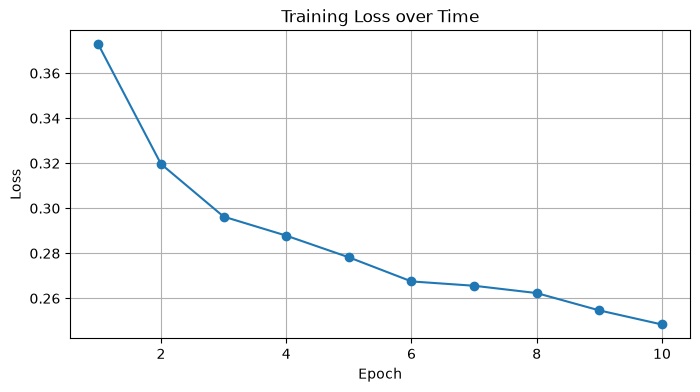

In [11]:
plt.figure(figsize=(8,4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.grid(True)
plt.show()

### Loading saved model post kernel restart

In [8]:
model = UNet().to(device)

model.load_state_dict(
    torch.load("sar_unet_checkpoint.pt", map_location=device)
)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


### Model Evaluation

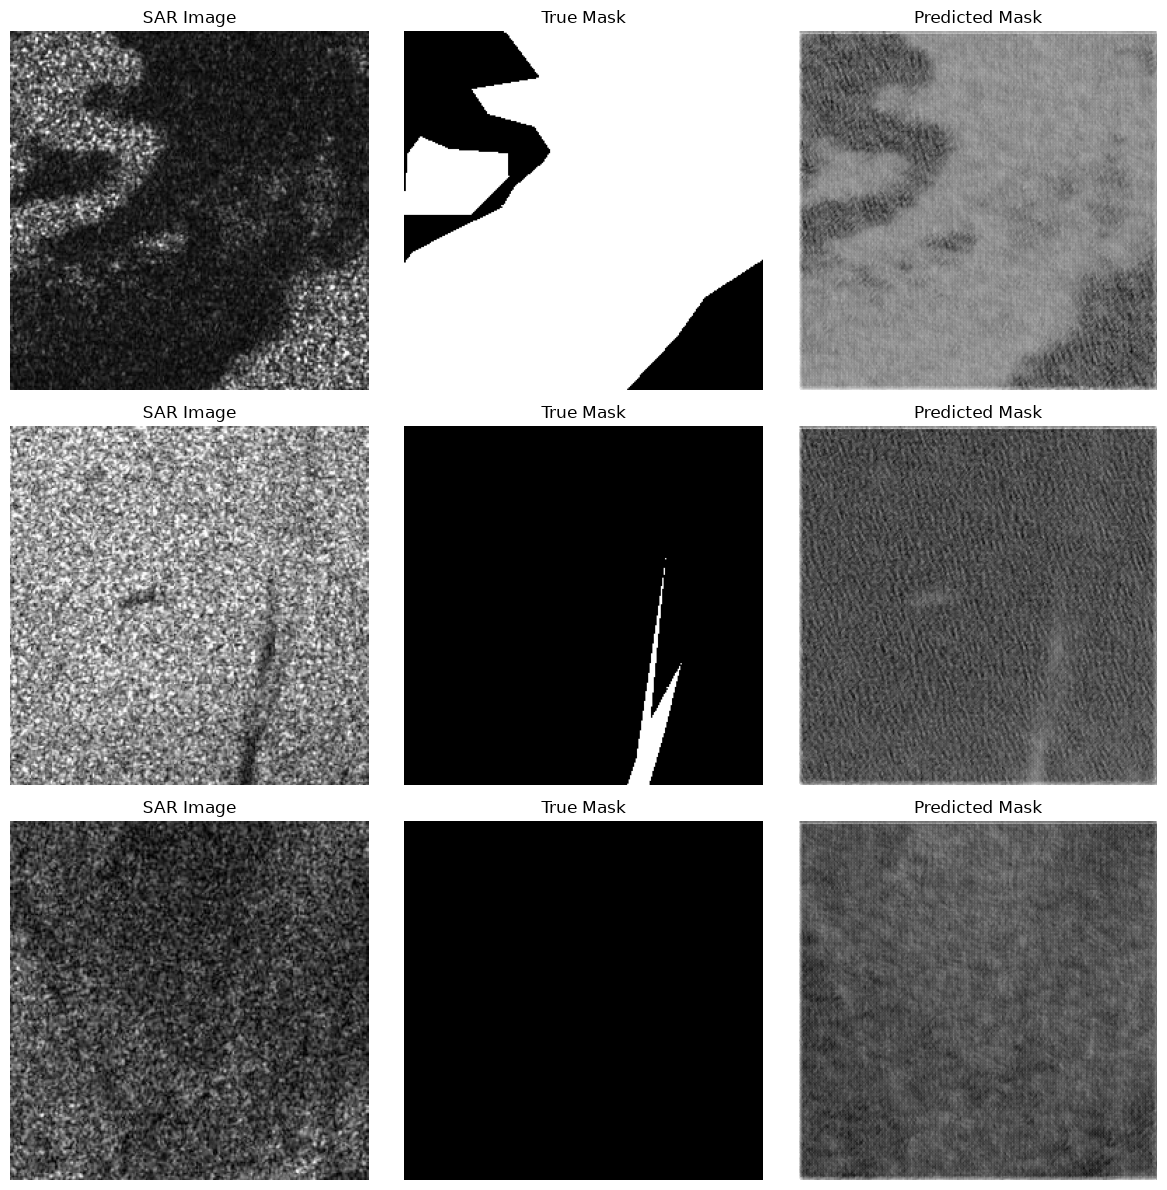

In [9]:
model.eval()

test_imgs, test_labels = next(iter(test_loader))
test_imgs, test_labels = test_imgs.to(device), test_labels.to(device)

with torch.no_grad():
    predictions = model(test_imgs)

num_examples = 3
fig, axes = plt.subplots(num_examples, 3, figsize = (12, 4 * num_examples))

for i in range(num_examples):
    img = test_imgs[i, 0].cpu().numpy()
    true_mask = test_labels[i, 0].cpu().numpy()
    pred_mask = predictions[i, 0].cpu().numpy()

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title("SAR Image")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(true_mask, cmap="gray")
    axes[i, 1].set_title("True Mask")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_mask, cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()